In [1]:
import os
import sys
project_dir = os.path.dirname(os.getcwd())
sys.path.append(project_dir)

from utils.summary import get_model_stats

import torch
import torch.nn.functional as F

In [2]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [3]:
from data.voc import get_voc_pipeline

train_loader, val_loader, test_loader = get_voc_pipeline(batch_size=4)
sample_x, sample_y = next(iter(train_loader))
print(sample_x.shape)
print(sample_y.shape)

Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
torch.Size([4, 3, 256, 256])
torch.Size([4, 1, 256, 256])


In [ ]:
import segmentation_models_pytorch as smp
import torch.nn as nn

# Option 1: UNet with ResNet50 encoder pretrained on ImageNet
teacher_model_resnet = smp.Unet(
    encoder_name="resnet50",
    encoder_weights="imagenet",
    in_channels=3,         # Assuming 3 input channels (RGB)
    classes=2,            # Your number of classes
    activation=None       # Return logits for distillation
)
print(f"Teacher UNet (ResNet50) parameters: {sum(p.numel() for p in teacher_model_resnet.parameters()):,}")

# Option 2: UNet with EfficientNet-b4 encoder pretrained on ImageNet
teacher_model_efficientnet = smp.Unet(
    encoder_name="efficientnet-b4",
    encoder_weights="imagenet",
    in_channels=3,
    classes=2,
    activation=None
)
print(f"Teacher UNet (EfficientNet-b4) parameters: {sum(p.numel() for p in teacher_model_efficientnet.parameters()):,}")

In [4]:
from models.unet import TeacherUNet
from models.unet import StudentUNet

teacher = TeacherUNet(in_channels=3, num_classes=21).to(device)
student = StudentUNet(in_channels=3, num_classes=21).to(device)

# sample = torch.randn(16, 3, 32, 32).to(device)
sample = sample_x.to(device)
with torch.no_grad():
    print("Teacher model stats:")
    pred = teacher(sample)
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("Student model stats:")
    pred = student(sample)
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

Teacher model stats:


Unsupported operator aten::max_pool2d encountered 4 time(s)
Unsupported operator aten::max_pool2d encountered 3 time(s)


flops: 193260945408
params: 31044821
Student model stats:
flops: 20193476608
params: 950069


In [5]:
import torch.optim as optim
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from utils.plots import plot_training_metrics
import tqdm
from torch.utils.data import DataLoader
import numpy as np

In [6]:
def train_model(train_loader: DataLoader, model: nn.Module, criterion: nn.Module, optimizer: nn.Module,
                scheduler: nn.Module=None, device: str='cpu') -> list:
    """
    Train the model for one epoch.

    Args:
        model: The PyTorch model to train.
        train_loader: DataLoader for the training data.
        optimizer: Optimizer for updating model parameters.
        criterion: Loss function.
        device: Device to run the training on ('cpu' or 'cuda').

    Returns:
        list: Collection of train losses.
    """
    model.train()
    epoch_losses = []
    for inputs, targets in tqdm.tqdm(train_loader, desc='training...', file=sys.stdout):
        inputs = inputs.to(device)
        targets = targets.squeeze(1).long().to(device)
        preds = model(inputs)
        loss = criterion(preds, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_losses.append(loss.item())
        if scheduler and isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(loss.item())
        elif scheduler:
            scheduler.step()
    return epoch_losses


def evaluate_model(val_loader: DataLoader, model: nn.Module, criterion: nn.Module, device: str='cpu') -> list:
    """
    Evaluate the model on validation data.

    Args:
        model: The PyTorch model to evaluate.
        val_loader: DataLoader for the validation data.
        criterion: Loss function.
        device: Device to run the evaluation on ('cpu' or 'cuda').

    Returns:
        list: Collection of metrics.
    """
    model.eval()
    epoch_metrics = []
    with torch.no_grad():
        for inputs, targets in tqdm.tqdm(val_loader, desc='evaluating...', file=sys.stdout):
            inputs = inputs.to(device)
            targets = targets.squeeze(1).long().to(device)
            preds = model(inputs)
            loss = criterion(preds, targets)
            epoch_metrics.append(loss)
    return epoch_metrics

In [7]:
import torch
import torch.nn as nn

class MIoU(nn.Module):
    def __init__(self, num_classes=21, ignore_index=255):
        super(MIoU, self).__init__()
        self.num_classes = num_classes
        self.ignore_index = ignore_index
        self.reset()
        
    def reset(self):
        self.intersection = torch.zeros(self.num_classes)
        self.union = torch.zeros(self.num_classes)
        
    def forward(self, outputs, targets):
        """
        Args:
            outputs: [B, C, H, W] tensor of raw model outputs (logits)
            targets: [B, H, W] tensor of ground truth labels
        Returns:
            mean IoU score (scalar)
        """
        # Convert logits to predictions
        preds = torch.argmax(outputs, dim=1)  # [B, H, W]
        
        batch_size = outputs.size(0)
        mean_iou = 0.0
        
        for b in range(batch_size):
            current_pred = preds[b]  # [H, W]
            current_target = targets[b]  # [H, W]
            
            # Create mask for valid pixels (not ignore_index)
            valid_mask = current_target != self.ignore_index
            
            # Calculate per-class IoU
            class_iou_sum = 0.0
            valid_classes = 0
            
            for cls in range(self.num_classes):
                pred_mask = (current_pred == cls) & valid_mask
                target_mask = (current_target == cls) & valid_mask
                
                intersection = torch.logical_and(pred_mask, target_mask).sum().item()
                union = torch.logical_or(pred_mask, target_mask).sum().item()
                
                # Only count classes that appear in the ground truth
                if union > 0:
                    class_iou_sum += intersection / union
                    valid_classes += 1
            
            # Average IoU across valid classes for this image
            if valid_classes > 0:
                mean_iou += class_iou_sum / valid_classes
        
        # Average across batch
        return mean_iou / batch_size if batch_size > 0 else 0.0
    
    # Added for compatibility with previous evaluation function
    def compute(self):
        # For this implementation compute() is not needed since forward() calculates directly
        # But we keep it for interface compatibility
        return self.intersection.sum() / self.union.sum() if self.union.sum() > 0 else 0.0
    
    # Added for compatibility with previous training loop
    def update(self, outputs, targets):
        # Calculate batch IoU and accumulate stats
        with torch.no_grad():
            preds = torch.argmax(outputs, dim=1)
            
            for cls in range(self.num_classes):
                valid_mask = targets != self.ignore_index
                pred_mask = (preds == cls) & valid_mask
                target_mask = (targets == cls) & valid_mask
                
                intersection = torch.logical_and(pred_mask, target_mask).sum().item()
                union = torch.logical_or(pred_mask, target_mask).sum().item()
                
                self.intersection[cls] += intersection
                self.union[cls] += union

/home/dodogama/anaconda3/envs/stock_ts/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


training...:   0%|          | 0/366 [00:00<?, ?it/s]

evaluating...: 100%|██████████| 363/363 [00:28<00:00, 12.67it/s]
Epoch 1: New best miou: 0.2218 saving model...
evaluating...: 100%|██████████| 363/363 [00:30<00:00, 11.89it/s]
Epoch 3: New best miou: 0.2228 saving model...
evaluating...: 100%|██████████| 363/363 [00:31<00:00, 11.47it/s]
Epoch 5: New best miou: 0.2315 saving model...
evaluating...: 100%|██████████| 363/363 [00:29<00:00, 12.12it/s]
Epoch 7: New best miou: 0.2323 saving model...
evaluating...: 100%|██████████| 363/363 [00:28<00:00, 12.69it/s]
Epoch 17: Early stop triggered.


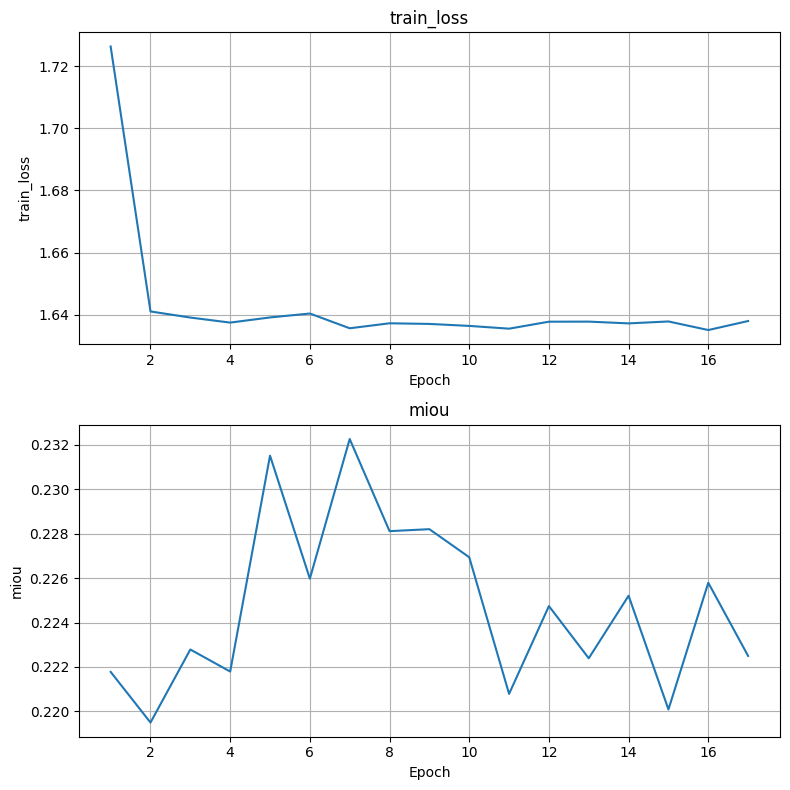

In [8]:

train_criterion = nn.CrossEntropyLoss(ignore_index=255)
val_criterion = MIoU()
optimizer = optim.Adam(teacher.parameters(), lr=0.001) 
# optim.SGD(teacher.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
# scheduler = StepLR(optimizer, step_size=30, gamma=0.1)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
teacher_path = f'../models/weights/teacher_seg.pth'

metrics = {"train_loss": [], "miou": []}
best_miou = 0.
patience = 10
counter = 0
epochs = 100

for epoch in range(epochs):
    train_loss = train_model(train_loader, teacher, train_criterion, optimizer, scheduler, device)
    val_loss = evaluate_model(val_loader, teacher, val_criterion, device)
    metrics['train_loss'].append(np.mean(train_loss))
    metrics['miou'].append(np.mean(val_loss))
    if metrics['miou'][-1] >= best_miou:
        best_miou = metrics['miou'][-1]
        counter = 0
        print(f"Epoch {epoch+1}: New best miou: {metrics['miou'][-1]:.4f} saving model...")
        state = {
            'epoch': epoch,
            'state_dict': teacher.state_dict(),
            'optimizer': optimizer.state_dict(),
        }
        state.update({k: metrics[k][-1] for k in metrics.keys()})
        torch.save(state, teacher_path)
    else:
        counter += 1
        if counter >= patience:
            print(f"Epoch {epoch+1}: Early stop triggered.")
            break
plot_training_metrics(metrics)

In [ ]:
# Optional: Warm-up scheduler (PyTorch >= 1.10)
from torch.optim.lr_scheduler import SequentialLR, LinearLR

warmup = LinearLR(optimizer, start_factor=1e-3, total_iters=5)
main_sched = StepLR(optimizer, step_size=30, gamma=0.1)
scheduler = SequentialLR(optimizer, schedulers=[warmup, main_sched], milestones=[5])

In [ ]:
from utils.pipeline import distill


# criterion = nn.CrossEntropyLoss(ignore_index=255)
teacher.load_state_dict(torch.load('../models/weights/teacher_seg.pth', map_location=device)['state_dict'])
criterion = MIoU(20)
optimizer = optim.SGD(student.parameters(), lr=0.01, momentum=0.9, weight_decay=1e-4)
scheduler = StepLR(optimizer, step_size=30, gamma=0.1)
aux_metrics = {'MIoU': MIoU(20)}
student_path = f'../models/weights/student_seg.pth'
metrics = distill(train_loader, val_loader, student, teacher, 10, criterion, optimizer, scheduler, 
                  device, aux_metrics, student_path)

/home/dodogama/code/project_compression/utils/pipeline.py:202: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_val_loss = torch.load(path)['val_loss']


distilling...:   0%|          | 0/46 [00:12<?, ?it/s]


RuntimeError: only batches of spatial targets supported (3D tensors) but got targets of size: : [32, 1, 256, 256]

In [ ]:
    student = mlp.mnist800().to(device)
    criterion = DistillationLoss(T=T)
    crossentropy = nn.CrossEntropyLoss()
    optimizer = optim.Adam(student.parameters(), lr=0.005)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)
    aux_metrics = {'accuracy': Accuracy()}
    path = f'../models/weights/student{T}.pth'

In [ ]:
def train_with_distillation(student_model, teacher_model, train_loader, optimizer, device, alpha=0.5, temperature=2.0):
    student_model.train()
    teacher_model.eval()  # Teacher is fixed during distillation
    
    total_loss = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        
        # Forward pass with student
        student_output = student_model(data)
        
        # Get teacher predictions (no grad needed)
        with torch.no_grad():
            teacher_output = teacher_model(data)
        
        # Calculate distillation loss
        loss = knowledge_distillation_loss(
            student_output, 
            teacher_output, 
            target, 
            alpha=alpha, 
            temperature=temperature
        )
        
        # Backward and optimize
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(train_loader)


if __name__ == '__main__':
    # Create models with different size ratios
    teacher = create_teacher_unet(in_channels=3, num_classes=2)
    student = create_student_unet(in_channels=3, num_classes=2, size_ratio=0.1)
    student_medium = create_student_unet(in_channels=3, num_classes=2, size_ratio=0.25)
    student_large = create_student_unet(in_channels=3, num_classes=2, size_ratio=0.5)
    
    # Print model sizes
    teacher_params = count_parameters(teacher)
    small_params = count_parameters(student)
    medium_params = count_parameters(student_medium)
    large_params = count_parameters(student_large)
    
    print(f"Teacher model parameters: {teacher_params:,}")
    print(f"Small student parameters: {small_params:,} (ratio: {teacher_params/small_params:.2f}x)")
    print(f"Medium student parameters: {medium_params:,} (ratio: {teacher_params/medium_params:.2f}x)")
    print(f"Large student parameters: {large_params:,} (ratio: {teacher_params/large_params:.2f}x)")
    
    # Sample usage of training loop
    """
    # Setup
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    teacher.to(device)
    student = student_medium.to(device)  # Choose which student to train
    
    # First train the teacher with standard cross-entropy loss
    # ...
    
    # Then train the student with distillation
    optimizer = torch.optim.Adam(student.parameters(), lr=0.001)
    
    for epoch in range(100):
        train_loss = train_with_distillation(
            student, 
            teacher, 
            train_loader, 
            optimizer, 
            device,
            alpha=0.5, 
            temperature=2.0
        )
        print(f"Epoch {epoch+1}, Loss: {train_loss:.4f}")
    """